In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PhysicalConstantsCGS as const
import pandas as pd
import pyathena

/usr/local/anaconda3/lib/python3.7/_collections_abc.py:666: MatplotlibDeprecationWarning: The global colormaps dictionary is no longer considered public API.
  self[key]


### Plot the ISM equilibrium curves for different Z

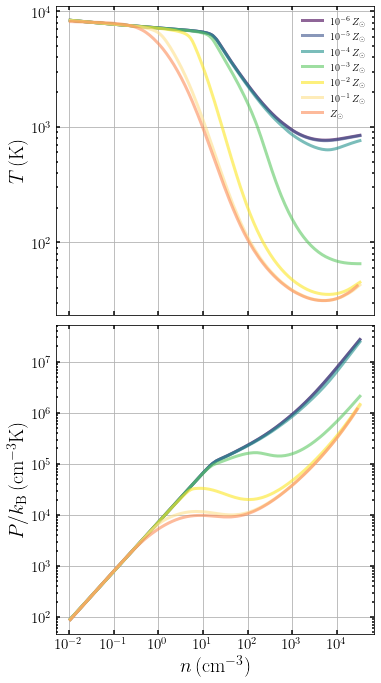

In [262]:
fig, axs = plt.subplots(nrows=2,sharex=True,figsize=(5.4,9.6),tight_layout=True)

Zvals = [-6,-5,-4,-3,-2,-1,0]
labels = [r"$10^{-6} \, Z_{\odot}$",r"$10^{-5} \, Z_{\odot}$", r"$10^{-4} \, Z_{\odot}$",r"$10^{-3} \, Z_{\odot}$",r"$10^{-2} \, Z_{\odot}$",r"$10^{-1} \, Z_{\odot}$",r"$ Z_{\odot}$"]
#colors from viridis colorbar
colors = ['#440154','#3B528B','#21918C','#5DC863','#FDE725','#FEE08B','#FC8D59']

for i,Z in enumerate(Zvals):
    data = np.loadtxt('AB_Z'+str(Z)).T
    axs[0].plot(data[0],data[2],label=labels[i],lw=3.0,alpha=0.6,color=colors[i])
    axs[1].plot(data[0],data[0]*data[2],lw=3.0,alpha=0.6,color=colors[i])

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[0].grid()
axs[1].grid()
axs[0].set_xticks([1.e-2,1.e-1,1.e0,1.e1,1.e2,1.e3,1.e4])
axs[0].set_ylabel(r'$T \, (\mathrm{K})$')
axs[1].set_ylabel(r'$P/k_{\rm B} \, (\mathrm{cm}^{-3} \mathrm{K})$')
axs[1].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')
axs[0].legend()

fig.savefig('ISMEq_Z.pdf',bbox_inches='tight')


## Equilibrium curves and abundances

In [2]:
def get_Hnuclei(file):
    ab = open(file,'r')
    f = np.loadtxt(file).T
    header = ab.readline()
    headers = header.split("#")[1].split("\n")[0].split(" ")
    nHnuclei = 0.0
    cols = int(np.shape(f)[0])
    for i in range(2,cols):
        if(headers[i] == "H"):
            nHnuclei += f[i]
        elif(headers[i] == "H2"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "H-"):
            nHnuclei += f[i]
        elif(headers[i] == "HD"):
            nHnuclei += f[i]
        elif(headers[i] == "OH"):
            nHnuclei += f[i]
        elif(headers[i] == "CH"):
            nHnuclei += f[i]
        elif(headers[i] == "CH2"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "CH3"):
            nHnuclei += f[i] * 3.0
        elif(headers[i] == "CH4"):
            nHnuclei += f[i] * 4.0
        elif(headers[i] == "H20_total"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "H+"):
            nHnuclei += f[i]
        elif(headers[i] == "H2+"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "HD+"):
            nHnuclei += f[i]
        elif(headers[i] == "OH+"):
            nHnuclei += f[i]
        elif(headers[i] == "H20+"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "H30+"):
            nHnuclei += f[i] * 3.0
        elif(headers[i] == "CH+"):
            nHnuclei += f[i]
        elif(headers[i] == "CH2+"):
            nHnuclei += f[i] * 2.0
        elif(headers[i] == "H3+"):
            nHnuclei += f[i] * 3.0

    ntot = f[0] #Get total number density since tabulated value scaled by this

    return nHnuclei*ntot
        
           


(1e-06, 5.0)

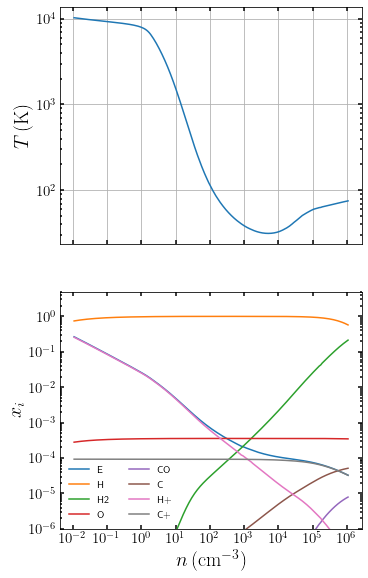

In [4]:
fig, axs = plt.subplots(nrows=2,sharex=True,figsize=(5.4,9.6))

#axs[0].plot(f[0],f[1])

f = np.loadtxt('AB_Z0').T

axs[0].plot(f[0],f[2])
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xticks([1.e-2,1.e-1,1.e0,1.e1,1.e2,1.e3,1.e4,1.e5,1.e6])
axs[0].set_ylabel(r'$T \, (\mathrm{K})$')

axs[0].grid()

ab = open('AB_Z0','r')
header = ab.readline()
headers = header.split("#")[1].split("\n")[0].split(" ")
filters = ["E","H","H+","H2","O","CO","C","C+"]
cols = int(np.shape(f)[0])

#Get H nuclei
nHnuclei = get_Hnuclei('AB_Z0')

ntot = f[0] #Get total number density since tabulated value scaled by this

for i in range(2,cols):
    if(headers[i] in filters):
        axs[1].plot(f[0],f[i]*ntot/nHnuclei,label=str(headers[i]))

axs[1].legend(ncol=2)
axs[1].set_yscale('log')

axs[1].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')
axs[1].set_ylabel(r'$x_{i}$')
axs[1].set_ylim(1.e-6,5.0)

#fig.savefig('Fig.pdf',bbox_inches='tight')


## Compare to Kim+23 and other studies

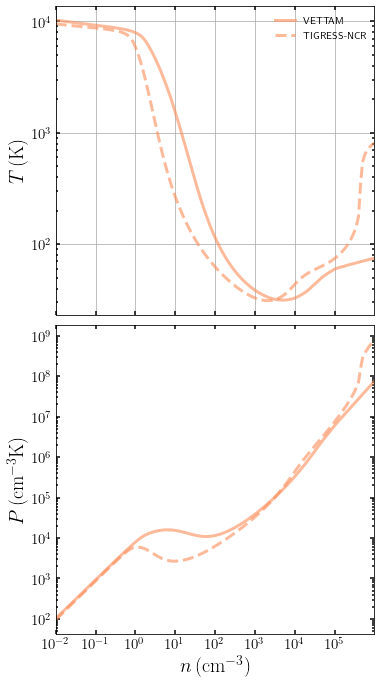

In [5]:
fig,axs = plt.subplots(nrows=2,sharex=True,figsize=(5.4,9.6),tight_layout=True)

f = np.loadtxt('AB_Z0').T

color = '#FC8D59'

axs[0].plot(f[0],f[2],color=color,lw=3.0,alpha=0.6,label="VETTAM")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylabel(r'$T \, (\mathrm{K})$')

axs[1].plot(f[0],f[0]*f[2],color=color,lw=3.0,alpha=0.6)

#Overplot Kim+ plot
#Unshielded
fname = "/Users/shm/Desktop/noshld_zg0.0_zd0.0_xi0.00.txt"
#Shielded
#fname = "/Users/shm/WORK/tigress_ncr_cooling/bin/shld_zg0.0_zd0.0_chi0.0_xi0.00.txt"
df = pd.read_csv(fname, sep='\s+')
df['T'] = df['pok']/(df['nH']*(1.1 + df['xe'] - df['xH2']))

axs[0].plot(df['nH'],df['T'],lw=3.0,alpha=0.6,ls='dashed',color=color,label="TIGRESS-NCR")
axs[1].plot(df['nH'],df['nH']*df['T'],lw=3.0,alpha=0.6,ls='dashed',color=color)
axs[0].grid()

axs[1].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')
axs[1].set_ylabel(r'$P \, (\mathrm{cm}^{-3} \mathrm{K})$')
axs[1].set_xlim(1.e-2,1.e6)
axs[1].set_xticks([1.e-2,1.e-1,1.e0,1.e1,1.e2,1.e3,1.e4,1.e5])
axs[1].set_yscale('log')

axs[0].legend()

#fig.savefig('VETTAM_TIGRESS.pdf',bbox_inches='tight')

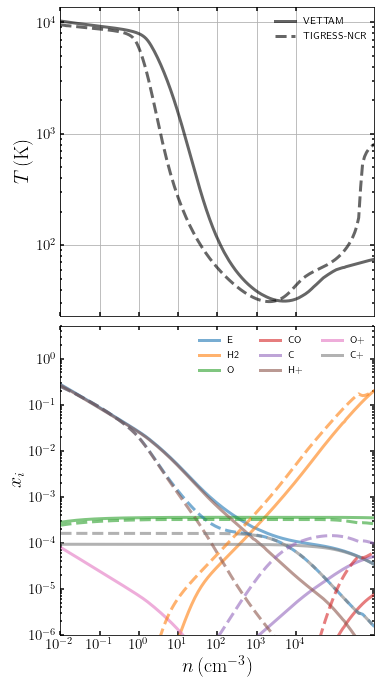

In [3]:
fig, axs = plt.subplots(nrows=2,sharex=True,figsize=(5.4,9.6),tight_layout=True)

f = np.loadtxt('AB_Z0').T

axs[0].plot(f[0],f[2],label="VETTAM",c='k',lw=3.0,alpha=0.6)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xticks([1.e-2,1.e-1,1.e0,1.e1,1.e2,1.e3,1.e4])
axs[0].set_ylabel(r'$T \, (\mathrm{K})$')

axs[0].grid()

#Shielded
#fname = "/Users/shm/WORK/tigress_ncr_cooling/bin/shld_zg0.0_zd0.0_chi0.0_xi0.00.txt"

#Unshielded
fname = "/Users/shm/Desktop/noshld_zg0.0_zd0.0_xi0.00.txt"
df = pd.read_csv(fname, sep='\s+')
df['T'] = df['pok']/(df['nH']*(1.1 + df['xe'] - df['xH2']))
axs[0].plot(df['nH'],df['T'],lw=3.0,alpha=0.6,ls='dashed',color='k',label="TIGRESS-NCR")

axs[0].legend()





ab = open('AB_Z0','r')
header = ab.readline()
headers = header.split("#")[1].split("\n")[0].split(" ")
filters = ["E","H+","H2","O","CO","C","C+","O+"]
cols = int(np.shape(f)[0])

#Get H nuclei
nHnuclei = get_Hnuclei('AB_Z0')
ntot = f[0] #Get total number density since tabulated value scaled by this

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

for i in range(2,cols):
    if(headers[i] in filters):
        axs[1].plot(f[0],f[i]*ntot/nHnuclei,label=str(headers[i]),lw=3.0,alpha=0.6)

axs[1].legend(ncol=3,loc='best')
axs[1].set_yscale('log')

axs[1].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')
axs[1].set_ylabel(r'$x_{i}$')
axs[1].set_ylim(1.e-6,5.0)

axs[1].set_xlim(1.e-2,1.e6)

T_kim = df['T']
nH_kim = df['nH']
P_kim = df['pok']
xH2_kim = df['xH2']
xe_kim = df['xe']
xHII_kim = df['xHII']

cl = pyathena.cool
xCII_kim = cl.get_xCII(nH=nH_kim, xe=xe_kim, xH2=xH2_kim, T=T_kim, Z_d=1.0, Z_g=1.0, xi_CR=2.e-16, G_PE=1.0, G_CI=1.0)
xOII_kim = xHII_kim * 3.2e-4
xCO_kim,ncrit = cl.get_xCO(nH=nH_kim, xH2=xH2_kim, xCII=xCII_kim,xOII=xOII_kim,Z_d=1.0, Z_g=1.0, xi_CR=2.e-16, chi_CO=1.0)

xOI_kim = np.clip(3.2e-4 - xOII_kim-xCO_kim, 1.e-20, None)
xCI_kim = np.clip(1.6e-4 - xCII_kim-xCO_kim, 1.e-20, None)

axs[1].plot(df['nH'],df['xe'],color=colors[0],ls='dashed',lw=3.0,alpha=0.6)
axs[1].plot(df['nH'],df['xHII'],color=colors[5],ls='dashed',lw=3.0,alpha=0.6)
axs[1].plot(df['nH'],xCII_kim,color=colors[7],ls='dashed',lw=3.0,alpha=0.6)
axs[1].plot(df['nH'],xH2_kim,color=colors[1],ls='dashed',lw=3.0,alpha=0.6)
axs[1].plot(df['nH'],xCI_kim,color=colors[4],ls='dashed',lw=3.0,alpha=0.6)
axs[1].plot(df['nH'],xOI_kim,color=colors[2],ls='dashed',lw=3.0,alpha=0.6)
axs[1].plot(df['nH'],xCO_kim,color=colors[3],ls='dashed',lw=3.0,alpha=0.6)

fig.savefig('VETTAM_TIGRESS.pdf',bbox_inches='tight')


### Plot heating and cooling terms

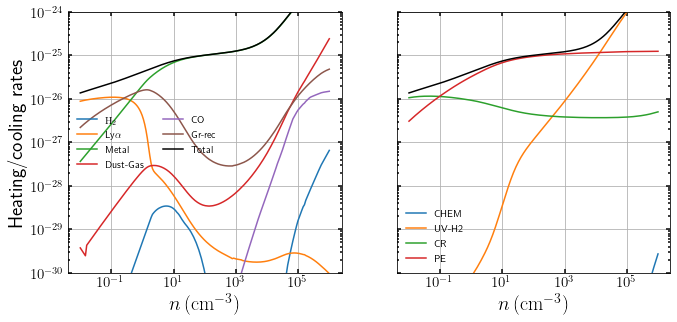

In [12]:
fig,axs = plt.subplots(ncols=2,figsize=(10.8,4.8),sharey=True)

f = np.loadtxt('AB_Z0').T
nH = get_Hnuclei('AB_Z0')

f = np.loadtxt('COOL_Z0').T
ngas = f[0]
cols = int(np.shape(f)[0])
cool = open('COOL_Z0','r')
header = cool.readline()
headers = header.split("#")[1].split("\n")[0].split(" ")

filters = ["ATOMIC","H2","Z","CO","DUST","DUSTGRREC"]
labels = ["Ly" + r"$\alpha$",r"$\rm{H}_2$","Metal","CO","Dust-Gas","Gr-rec"]

ind = 0
for i in range(3,cols):
    if(headers[i] in filters):
        ind = np.where(np.array(filters) == headers[i])[0][0]        
        axs[0].plot(ngas,f[i]/nH,label=str(labels[ind]))
        ind = ind+1

axs[0].plot(ngas,f[2]/nH,label='Total',c='k')

axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')
axs[0].set_ylabel('Heating/cooling rates')
axs[0].legend(ncol=2)

f = np.loadtxt('HEAT_Z0').T
ngas = f[0]
cols = int(np.shape(f)[0])
heat = open('HEAT_Z0','r')
header = heat.readline()
headers = header.split("#")[1].split("\n")[0].split(" ")

#Heating rates: chemical, compression, photodissociation/ionization, cosmic ray heating, photoelectric heating
filters = ["CHEM","AV","CR","DUST"]
labels = ["CHEM","UV-H2","CR","PE"]

ind = 0
for i in range(3,cols):
    if(headers[i] in filters):
        ind = np.where(np.array(filters) == headers[i])[0][0] 
        axs[1].plot(ngas,f[i]/nH,label=str(labels[ind]))

axs[1].plot(ngas,f[2]/nH,c='k')

axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].legend()

axs[1].set_xlabel(r'$n \, (\mathrm{cm}^{-3})$')

axs[0].set_ylim(1.e-30,1.e-24)

axs[0].grid()
axs[1].grid()

#fig.savefig('HeatingCooling.pdf',bbox_inches='tight')



(1e-35, 1e-18)

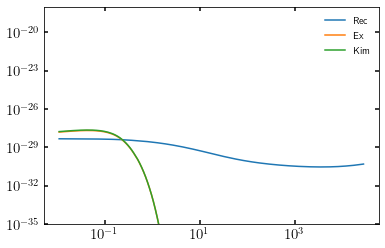

In [139]:
#Check Ly-alpha cooling

#Get n and T
f = np.loadtxt('fort.22').T
ndens, temp = f[0], f[1]

#Get xe and xH+
ne, nHp,nH = f[2], f[23], f[5]

#Get recombination cooling rate
cooling = 8.7e-27*np.sqrt(temp)*(temp/1.e3)**(-0.2)/(1.0+(temp/1.e6)**0.7)*ne*nHp

#collisional excitation rate
cooling_ex = 7.5e-19/(1.e0+np.sqrt(temp/1.e5))*np.exp(-1.18348e5/temp)*ne*nH

#Ly-alpha Kim
T4 = temp/1.e4
Lya = 5.31e-8 * (T4)**(0.15)/(1+(T4/5)**0.65) * np.exp(-11.84/T4) * 1.184e5 * const.k_BoltzmannConstant * ne*nH

plt.plot(ndens,cooling/nH,label='Rec')
plt.plot(ndens,cooling_ex/nH,label='Ex')
plt.plot(ndens,Lya/nH,label='Kim')
plt.yscale('log')
plt.xscale('log')

plt.legend()
plt.ylim(1.e-35,1.e-18)


### Checking convergence with tolerance

Text(0, 0.5, '$T \\, (\\mathrm{K})$')

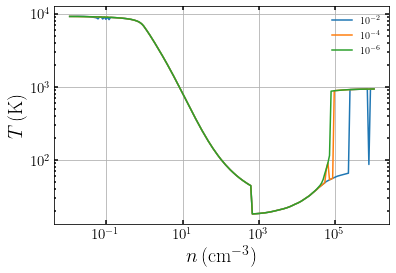

In [38]:
files = ["fort1e-2.22","fort1e-4.22","fort1e-6.22"]
labels = [r"$10^{-2}$",r"$10^{-4}$",r"$10^{-6}$"]
for i,file in enumerate(files):
    f = np.loadtxt(file).T
    plt.plot(f[0],f[1],label=labels[i])
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.xlabel(r'$n \, (\mathrm{cm}^{-3})$')
plt.ylabel(r'$T \, (\mathrm{K})$')

## Test Cooling function (test_cooling.f90) at a fixed density for different temperatures

(1e-06, 5.0)

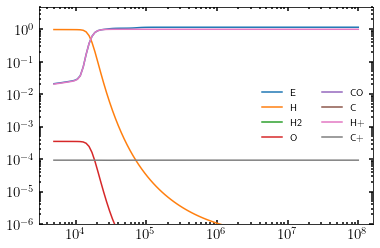

In [19]:
### Compute Kim+23 cooling rates using abundances of our system

#First get abundances from the abundances file
f = np.loadtxt('ABcoolingfunc.dat').T
ab = open('ABcoolingfunc.dat','r')
header = ab.readline()
headers = header.split("#")[1].split("\n")[0].split(" ")
filters = ["E","H","H+","H2","O","CO","C","C+"]
cols = int(np.shape(f)[0])

#Get H nuclei
nHnuclei = get_Hnuclei('ABcoolingfunc.dat')

for i in range(2,cols):
    if(headers[i] in filters):
        plt.plot(f[1],f[i]/nHnuclei,label=str(headers[i]))

plt.legend(ncol=2)
plt.xscale('log')
plt.yscale('log')

plt.ylim(1.e-6,5.0)


In [36]:
f = np.loadtxt('ABcoolingfunc.dat').T
#Get H nuclei
nHnuclei = get_Hnuclei('ABcoolingfunc.dat')
#Get individual cooling rates
hycooling = cl.coolLya(nH=f[0], T=f[1], xe=f[2]/nHnuclei, xHI=f[5]/nHnuclei)
hycollion = cl.coolHIion(nH=f[0], T=f[1], xe=f[2]/nHnuclei, xHI=f[5]/nHnuclei)
hyff = cl.coolffH(nH=f[0], T=f[1], xe=f[2]/nHnuclei, xHII=f[23]/nHnuclei)
hyrec = cl.coolrecH(nH=f[0], T=f[1], xe=f[2]/nHnuclei, xHII=f[23]/nHnuclei)
h2rovib = cl.coolH2rovib(nH=f[0], T=f[1], xHI=f[5]/nHnuclei, xH2=f[7]/nHnuclei)
H2_colldiss = cl.coolH2colldiss(nH=f[0], T=f[1], xHI=f[5]/nHnuclei, xH2=f[7]/nHnuclei)
AtomicCooling = hycooling + hycollion + hyff + hyrec + h2rovib

#xCII = cl.get_xCII(nH=f[0], xe=f[2]/nHnuclei, xH2=f[7]/nHnuclei, T=f[1], Z_d=1.0, Z_g=1.0, xi_CR=2.e-16, G_PE=1.0, G_CI=1.0)

CIICooling = cl.coolCII(f[0],f[1],f[2]/nHnuclei,f[5]/nHnuclei,f[7]/nHnuclei,f[33]/nHnuclei)
OICooling = cl.coolOI(f[0],f[1],f[2]/nHnuclei,f[5]/nHnuclei,f[7]/nHnuclei,f[10]/nHnuclei)
CICooling = cl.coolCI(f[0],f[1],f[2]/nHnuclei,f[5]/nHnuclei,f[7]/nHnuclei,f[16]/nHnuclei)

/usr/local/anaconda3/lib/python3.7/site-packages/pyathena/microphysics/cool.py:297: RuntimeWarning: overflow encountered in exp
  k10e = fac * np.exp(lngamma10e)/g1CI_
/usr/local/anaconda3/lib/python3.7/site-packages/pyathena/microphysics/cool.py:298: RuntimeWarning: overflow encountered in exp
  k20e = fac * np.exp(lngamma20e)/g2CI_
/usr/local/anaconda3/lib/python3.7/site-packages/pyathena/microphysics/cool.py:299: RuntimeWarning: overflow encountered in exp
  k21e = fac * np.exp(lngamma21e)/g2CI_
/usr/local/anaconda3/lib/python3.7/site-packages/pyathena/microphysics/cool.py:665: RuntimeWarning: overflow encountered in multiply
  a0 = R10*R20 + R10*R21 + q12*R20
/usr/local/anaconda3/lib/python3.7/site-packages/pyathena/microphysics/cool.py:666: RuntimeWarning: overflow encountered in multiply
  a1 = q01*R20 + q01*R21 + R21*q02
/usr/local/anaconda3/lib/python3.7/site-packages/pyathena/microphysics/cool.py:667: RuntimeWarning: overflow encountered in multiply
  a2 = q02*R10 + q02*q12 + 

Text(0.5, 0, '$T \\, (\\mathrm{K})$')

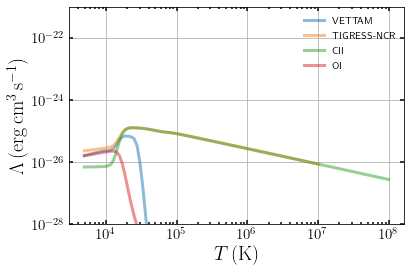

In [37]:
f = np.loadtxt('coolingfunc.dat').T
plt.plot(f[1],f[7],lw=3.0,alpha=0.5,label='VETTAM')
plt.plot(f[1],CIICooling+OICooling+CICooling,lw=3.0,alpha=0.5,label='TIGRESS-NCR')
plt.plot(f[1],CIICooling,lw=3.0,alpha=0.5,label='CII')
plt.plot(f[1],OICooling,lw=3.0,alpha=0.5,label='OI')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.ylim(1.e-28,1.e-21)

plt.legend()

plt.ylabel(r'$\Lambda \, (\mathrm{erg} \, \mathrm{cm}^{3} \, \mathrm{s}^{-1})$')
plt.xlabel(r'$T \, (\mathrm{K})$')

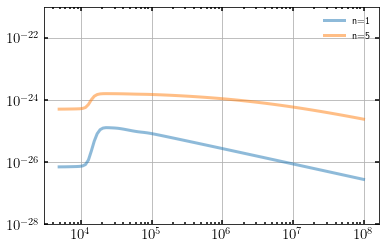

In [46]:
f = np.loadtxt('ABcoolingfunc.dat').T
CIICooling = cl.coolCII(f[0],f[1],f[2]/nHnuclei,f[5]/nHnuclei,f[7]/nHnuclei,f[33]/nHnuclei)
plt.plot(f[1],CIICooling,lw=3.0,alpha=0.5,label='n=1')
CIICooling = cl.coolCII(f[0]*100,f[1],f[2]/nHnuclei,f[5]/nHnuclei,f[7]/nHnuclei,f[33]/nHnuclei)
plt.plot(f[1],CIICooling,lw=3.0,alpha=0.5,label='n=5')

plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.ylim(1.e-28,1.e-21)

plt.legend()

Text(0.5, 0, '$T \\, (\\mathrm{K})$')

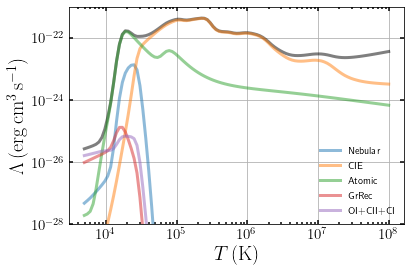

In [14]:
f = np.loadtxt('coolingfunc.dat').T

plt.plot(f[1],f[2],c='k',lw=3.0,alpha=0.5)
plt.plot(f[1],f[3],lw=3.0,alpha=0.5,label='Nebular')
plt.plot(f[1],f[4],lw=3.0,alpha=0.5,label='CIE')
plt.plot(f[1],f[5],lw=3.0,alpha=0.5,label='Atomic')
plt.plot(f[1],f[6],lw=3.0,alpha=0.5,label='GrRec')
plt.plot(f[1],f[7],lw=3.0,alpha=0.5,label='OI+CII+CI')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.ylim(1.e-28,1.e-21)

plt.legend()

plt.ylabel(r'$\Lambda \, (\mathrm{erg} \, \mathrm{cm}^{3} \, \mathrm{s}^{-1})$')
plt.xlabel(r'$T \, (\mathrm{K})$')

#plt.savefig('CoolingFunctionTemperature.pdf',bbox_inches='tight')
